# Xception PyTorch Local GPU Training — May11
**Pipeline:** Xception backbone -> 128-d embedding head -> 6-class classifier  
Training uses local laptop GPU, Keras-equivalent augmentation, full metric reporting, plots, inference timing, model size/parameter reporting, and saved embeddings/results.  
All outputs saved to `Xception_May11_Results/`.  
Dataset: May11 rebalanced split — 1,750 train / 250 val / 500 test per class (15,000 total).


In [1]:
# ================================================
# Cell 1 — Imports & Config
# ================================================
# ── Standard library ──────────────────────────────────────────
# os, pathlib : file path construction and directory management
# time        : wall-clock timing for inference benchmarking
import os
import time
from pathlib import Path


# ── Scientific computing ───────────────────────────────────────
# numpy  : array operations, random sampling, metric aggregation
# pandas : tabular results and CSV export
# matplotlib: training curve and metric plot generation
# tqdm   : progress bars for training and evaluation loops
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ── PyTorch and timm ───────────────────────────────────────────
# torch           : tensor operations and autograd engine
# torch.nn        : layer definitions (Linear, Dropout)
# torch.optim     : Adam optimiser
# timm            : third-party model library providing Xception
#                   (not available in standard torchvision)
# torchvision     : dataset utilities and standard transforms
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm


# ── Evaluation metrics ─────────────────────────────────────────
# sklearn: classification report, confusion matrix, per-class
#         precision/recall/F1 for full evaluation pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)


# ── Dataset and output paths ───────────────────────────────────
# Dataset is pre-split into Training / Validation / Testing.
# All results (model weights, plots, CSVs) are saved to OUTPUT_DIR.
# ── Paths ──────────────────────────────────────
BASE_DATASET = "/home/jenarththan/Desktop/FYP/May11/Dataset"
TRAIN_PATH   = os.path.join(BASE_DATASET, "Training")
VAL_PATH     = os.path.join(BASE_DATASET, "Validation")
TEST_PATH    = os.path.join(BASE_DATASET, "Testing")

NOTEBOOK_DIR = "/home/jenarththan/Desktop/FYP/May11/Notebooks"
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, "Xception_May11_Results")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")


# ── Training hyperparameters ───────────────────────────────────
# IMG_SIZE=224      : Xception standard input resolution
# BATCH_SIZE=32     : balances GPU memory usage and gradient noise
# EPOCHS=50         : maximum epochs (early stopping usually stops earlier)
# PATIENCE=5        : stop if val_loss does not improve for 5 consecutive epochs
# MIN_EPOCHS_BEFORE_STOP=20: ensures meaningful training before early stop
# LR=1e-5           : low learning rate for stable fine-tuning of pretrained weights
# SEED=42           : fixed random seed for fully reproducible results
# EMBED_DIM=128     : dimensionality of the custom classification head embedding
# ── Hyperparameters ─────────────────────────────
CLASS_NAMES     = ['0', '100', '500', '1000', '1500', '2000']
NUM_CLASSES     = len(CLASS_NAMES)
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS          = 50
PATIENCE        = 5
MIN_EPOCHS_BEFORE_STOP = 20
LR              = 1e-5
SEED            = 42
TRAIN_PER_CLASS = 1750
VAL_PER_CLASS   = 250
EMBED_DIM       = 128
NUM_WORKERS     = 0
USE_PRETRAINED  = True
REQUIRE_CUDA    = True


# ── Device configuration ───────────────────────────────────────
# REQUIRE_CUDA=True ensures training always runs on GPU.
# cudnn.benchmark=True lets cuDNN auto-tune convolution kernels.
# PIN_MEMORY=True speeds up CPU->GPU data transfer via page-locked memory.
# ── Device setup ────────────────────────────────
if REQUIRE_CUDA and not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. Open this notebook in the GPU-enabled PyTorch environment, check nvidia-smi, then rerun.")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    PIN_MEMORY = True
    torch.backends.cudnn.benchmark = True
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_memory_gb = gpu_props.total_memory / 1e9
else:
    DEVICE = torch.device("cpu")
    PIN_MEMORY = False
    gpu_name = "CUDA not available"
    gpu_memory_gb = 0.0


# Fix all random seeds for reproducibility across numpy, PyTorch, and CUDA
rng = np.random.RandomState(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("Device information")
print("=" * 50)
print(f"Device used       : {DEVICE}")
print(f"Device type       : {DEVICE.type}")
print(f"Graphics card/GPU : {gpu_name}")
if torch.cuda.is_available():
    print(f"GPU memory        : {gpu_memory_gb:.1f} GB")
    print(f"CUDA version      : {torch.version.cuda}")
print(f"PyTorch version   : {torch.__version__}")
print("=" * 50)


Output directory: /home/jenarththan/Desktop/FYP/May11/Notebooks/Xception_May11_Results
Device information
Device used       : cuda
Device type       : cuda
Graphics card/GPU : NVIDIA GeForce RTX 3050 Ti Laptop GPU
GPU memory        : 4.0 GB
CUDA version      : 12.4
PyTorch version   : 2.6.0+cu124


In [2]:
# ================================================
# Cell 2 — Dataset Loading + Augmentation
# ================================================
# ── Custom dataset class ───────────────────────────────────────
# torchvision ImageFolder sorts classes alphabetically by default,
# producing incorrect order (0,1000,1500,100,2000,500).
# OrderedImageFolder overrides find_classes() to enforce the correct
# numeric milling order: 0, 100, 500, 1000, 1500, 2000.
class OrderedImageFolder(datasets.ImageFolder):
    """ImageFolder with a fixed class order instead of alphabetical."""
    def find_classes(self, directory):
        classes = CLASS_NAMES
        class_to_idx = {c: i for i, c in enumerate(classes)}
        missing = [c for c in classes if c not in os.listdir(directory)]
        if missing:
            raise FileNotFoundError(f"Missing class folders in {directory}: {missing}")
        return classes, class_to_idx


# ── Training augmentation pipeline ─────────────────────────────
# RandomHorizontalFlip : aggregate orientation is arbitrary
# RandomRotation(20)   : simulate varied camera angles
# RandomAffine(scale)  : simulate varying specimen-to-camera distance
# Normalize(ImageNet)  : required for pretrained Xception backbone
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# ── Evaluation transform (no augmentation) ─────────────────────
# Deterministic: only resize and ImageNet normalisation.
# Ensures consistent and reproducible validation/test evaluation.
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# ── Load pre-split datasets ────────────────────────────────────
# Dataset was split offline (SEED=42) into mutually exclusive
# train/val/test folders. train_eval_ds uses eval_transform for
# embedding extraction without augmentation noise.
# Load directly from pre-split folders (no Subset needed)
train_ds      = OrderedImageFolder(root=TRAIN_PATH, transform=train_transform)
train_eval_ds = OrderedImageFolder(root=TRAIN_PATH, transform=eval_transform)
val_ds        = OrderedImageFolder(root=VAL_PATH,   transform=eval_transform)
test_ds       = OrderedImageFolder(root=TEST_PATH,  transform=eval_transform)

assert train_ds.classes == CLASS_NAMES, "Train class order mismatch!"
assert val_ds.classes   == CLASS_NAMES, "Val class order mismatch!"
assert test_ds.classes  == CLASS_NAMES, "Test class order mismatch!"

print(f"Classes    : {CLASS_NAMES}")
print(f"Train      : {len(train_ds):,} images  ({len(train_ds)//NUM_CLASSES} per class)")
print(f"Validation : {len(val_ds):,} images  ({len(val_ds)//NUM_CLASSES} per class)")
print(f"Test       : {len(test_ds):,} images  ({len(test_ds)//NUM_CLASSES} per class)")


# ── DataLoaders ────────────────────────────────────────────────
# train_loader shuffles batches each epoch for stochastic gradient descent.
# val/test loaders are unshuffled for deterministic evaluation.
train_loader      = DataLoader(train_ds,      batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader        = DataLoader(val_ds,        batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
train_eval_loader = DataLoader(train_eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader       = DataLoader(test_ds,       batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Data loaders ready.")
print("Augmentation: horizontal flip, rotation +/-20 degrees, zoom 0.8-1.2")


Classes    : ['0', '100', '500', '1000', '1500', '2000']
Train      : 10,500 images  (1750 per class)
Validation : 1,500 images  (250 per class)
Test       : 3,000 images  (500 per class)
Data loaders ready.
Augmentation: horizontal flip, rotation +/-20 degrees, zoom 0.8-1.2


In [3]:
# ================================================
# Cell 3 — Model: Xception + 128-d Embedding Head
# ================================================
# ── Model architecture ─────────────────────────────────────────
# Xception backbone loaded via timm (not available in torchvision).
# Xception uses depthwise separable convolutions in an extreme
# Inception-style design, with 21.1M parameters and strong feature
# extraction for texture and shape classification tasks.
#
# timm.create_model() arguments:
#   num_classes=0    : removes the final classification head entirely,
#                      exposing raw backbone features (no nn.Identity needed)
#   global_pool='avg': applies global average pooling to produce a
#                      fixed-size 2048-d feature vector regardless of input size
#
# backbone.num_features (2048) is the timm attribute for output feature size.
# Custom head: Dropout(0.3) -> Linear(2048->128) -> ReLU -> Linear(128->6)
# return_embedding=True returns both logits and the 128-d embedding.
class XceptionClassifier(nn.Module):
    def __init__(self, num_classes=6, embedding_dim=128, p_drop=0.3, use_pretrained=True):
        super().__init__()
        try:
            # Load Xception from timm with pretrained ImageNet weights.
            # num_classes=0 removes the classifier head — backbone outputs 2048-d features.
            self.backbone = timm.create_model(
                "xception",
                pretrained=use_pretrained,
                num_classes=0,
                global_pool="avg",
            )
            print(f"Loaded Xception model from timm (pretrained={use_pretrained}).")
        except Exception as exc:
            raise RuntimeError(
                "Could not create Xception with timm. Install timm in this Jupyter environment "
                "and make sure pretrained weights are available, then rerun. Original error: "
                f"{exc}"
            )

        # timm exposes num_features (2048 for Xception) as a model attribute
        in_features = self.backbone.num_features
        # Custom head: reduces 2048-d backbone features to 128-d embedding
        self.embedding_head = nn.Sequential(
            nn.Dropout(p_drop),
            nn.Linear(in_features, embedding_dim),
            nn.ReLU(inplace=True),
        )
        # Final linear layer maps 128-d embedding to 6-class logits
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embedding=False):
        features = self.backbone(x)
        emb = self.embedding_head(features)
        logits = self.classifier(emb)
        if return_embedding:
            return logits, emb
        return logits

model = XceptionClassifier(
    num_classes=NUM_CLASSES,
    embedding_dim=EMBED_DIM,
    p_drop=0.3,
    use_pretrained=USE_PRETRAINED,
).to(DEVICE)


# CrossEntropyLoss for multi-class classification
# Adam optimiser with lr=1e-5 for stable fine-tuning of pretrained weights
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

TOTAL_PARAMS = sum(p.numel() for p in model.parameters())
TRAINABLE_PARAMS = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {TOTAL_PARAMS:,}")
print(f"Trainable parameters: {TRAINABLE_PARAMS:,}")
print(f"Embedding dimension : {EMBED_DIM}")


/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Loaded Xception model from timm (pretrained=True).
Total parameters    : 21,069,998
Trainable parameters: 21,069,998
Embedding dimension : 128


/tmp/ipykernel_18018/1043671099.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_18018/1043671099.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_18018/1043671099.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...

Epoch 25/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 25]  Train Acc: 0.8773  Val Acc: 0.8333  Train Loss: 0.2987  Val Loss: 0.3848


Epoch 26/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

Epoch 26/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 26]  Train Acc: 0.8832  Val Acc: 0.8480  Train Loss: 0.2939  Val Loss: 0.3876
Early stopping at epoch 26 after 5 epochs without improvement.

Training complete. Best model -> /home/jenarththan/Desktop/FYP/May11/Notebooks/Xception_May11_Results/best_xception_model.pth


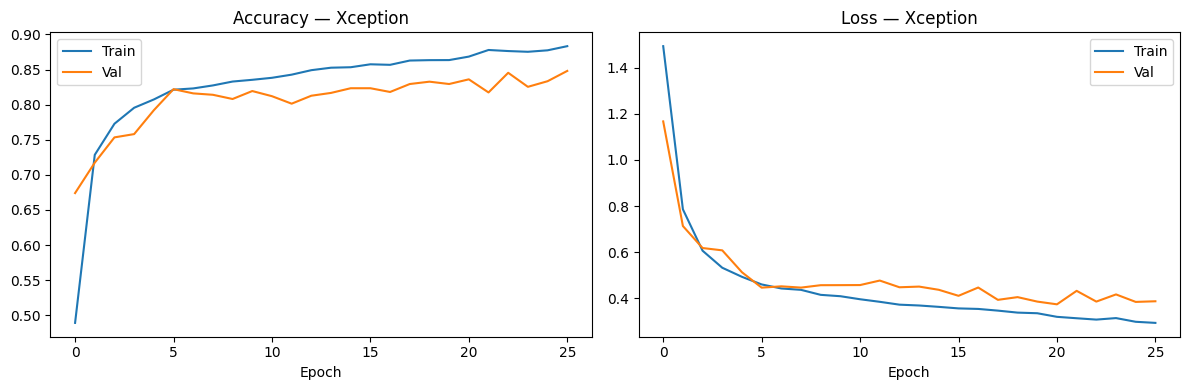

Training curves saved.
Training history saved.


In [4]:
# ================================================
# Cell 4 — Training  (AMP + early stopping + save best)
# ================================================
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_xception_model.pth")

# ── Automatic Mixed Precision (AMP) ────────────────────────────
# Runs forward passes in float16 where safe, float32 where needed.
# Gives ~1.5-2x speedup on modern NVIDIA GPUs with no accuracy loss.
use_amp = DEVICE.type == "cuda"
scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)

# ── Early stopping state ───────────────────────────────────────
# Track best validation loss; save weights whenever val_loss improves.
best_val_loss = float('inf')
epochs_no_improve = 0
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []


# ── Training loop ──────────────────────────────────────────────
# Each epoch: (1) train, (2) validate, (3) early stopping check,
# (4) save best model if val_loss improved.
for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        # torch.no_grad() disables gradient tracking, saving memory
        with torch.no_grad():
            preds = outputs.argmax(1)

        run_loss    += loss.item() * inputs.size(0)
        run_correct += (preds == labels).sum().item()
        run_total   += inputs.size(0)

    train_loss = run_loss / run_total
    train_acc  = run_correct / run_total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    # torch.no_grad() disables gradient tracking, saving memory
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
            inputs = inputs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            val_loss    += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += inputs.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"[Epoch {epoch:02d}]  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    # ── Early stopping: train at least 20 epochs, then stop after 5 no-improvement epochs ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Best model saved  (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epoch < MIN_EPOCHS_BEFORE_STOP:
            print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE}, "
                  f"but continuing until at least epoch {MIN_EPOCHS_BEFORE_STOP}.")
        elif epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} after {epochs_no_improve} epochs without improvement.")
            break

print(f"\nTraining complete. Best model -> {BEST_MODEL_PATH}")


# ── Learning curves ────────────────────────────────────────────
# Plot training/validation accuracy and loss; save PNG and CSV.
# ── Learning curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_acc_hist, label='Train')
axes[0].plot(val_acc_hist, label='Val')
axes[0].set_title("Accuracy — Xception")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(train_loss_hist, label='Train')
axes[1].plot(val_loss_hist, label='Val')
axes[1].set_title("Loss — Xception")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Training curves saved.")

pd.DataFrame({
    "epoch": range(1, len(train_loss_hist) + 1),
    "train_loss": train_loss_hist,
    "val_loss": val_loss_hist,
    "train_acc": train_acc_hist,
    "val_acc": val_acc_hist,
}).to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
print("Training history saved.")


In [5]:
# ================================================
# Cell 5 — Model / Device / Size Summary
# ================================================
# Helper to read saved model file size in megabytes
def get_file_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2) if os.path.exists(path) else np.nan

MODEL_SIZE_MB = get_file_size_mb(BEST_MODEL_PATH)


# ── Model and device summary ───────────────────────────────────
# Captures training environment details and model properties
# in a single CSV for reproducibility and result reporting.
summary = {
    "model": "Xception PyTorch",
    "device_used": str(DEVICE),
    "device_type": DEVICE.type,
    "graphics_card": gpu_name,
    "gpu_memory_gb": round(gpu_memory_gb, 3),
    "torch_version": torch.__version__,
    "cuda_version": torch.version.cuda if torch.cuda.is_available() else "N/A",
    "total_parameters": TOTAL_PARAMS,
    "trainable_parameters": TRAINABLE_PARAMS,
    "model_size_mb": round(MODEL_SIZE_MB, 3),
    "embedding_dim": EMBED_DIM,
    "batch_size": BATCH_SIZE,
    "image_size": IMG_SIZE,
    "epochs_configured": EPOCHS,
    "patience": PATIENCE,
    "min_epochs_before_stop": MIN_EPOCHS_BEFORE_STOP,
    "best_model_path": BEST_MODEL_PATH,
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(OUTPUT_DIR, "model_device_size_summary.csv"), index=False)

print("\nMODEL / DEVICE / SIZE SUMMARY")
print("=" * 70)
for k, v in summary.items():
    print(f"{k:24}: {v}")
print("=" * 70)



MODEL / DEVICE / SIZE SUMMARY
model                   : Xception PyTorch
device_used             : cuda
device_type             : cuda
graphics_card           : NVIDIA GeForce RTX 3050 Ti Laptop GPU
gpu_memory_gb           : 3.963
torch_version           : 2.6.0+cu124
cuda_version            : 12.4
total_parameters        : 21069998
trainable_parameters    : 21069998
model_size_mb           : 80.678
embedding_dim           : 128
batch_size              : 32
image_size              : 224
epochs_configured       : 50
patience                : 5
min_epochs_before_stop  : 20
best_model_path         : /home/jenarththan/Desktop/FYP/May11/Notebooks/Xception_May11_Results/best_xception_model.pth



     #    True Label    Pred Label   Correct


Inference:   0%|          | 0/94 [00:00<?, ?it/s]

     0             0             0       YES
     1             0             0       YES
     2             0           500       NO 
     3             0             0       YES
     4             0             0       YES
     5             0             0       YES
     6             0             0       YES
     7             0           500       NO 
     8             0             0       YES
     9             0             0       YES
    10             0           500       NO 
    11             0           500       NO 
    12             0             0       YES
    13             0             0       YES
    14             0           500       NO 
    15             0           500       NO 
    16             0             0       YES
    17             0             0       YES
    18             0             0       YES
    19             0           500       NO 
    20             0             0       YES
    21             0           500       NO 
    22    

/tmp/ipykernel_18018/720686598.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


    32             0             0       YES
    33             0             0       YES
    34             0             0       YES
    35             0             0       YES
    36             0             0       YES
    37             0             0       YES
    38             0             0       YES
    39             0           500       NO 
    40             0             0       YES
    41             0             0       YES
    42             0             0       YES
    43             0             0       YES
    44             0             0       YES
    45             0             0       YES
    46             0             0       YES
    47             0             0       YES
    48             0             0       YES
    49             0             0       YES
    50             0             0       YES
    51             0             0       YES
    52             0             0       YES
    53             0           500       NO 
    54    

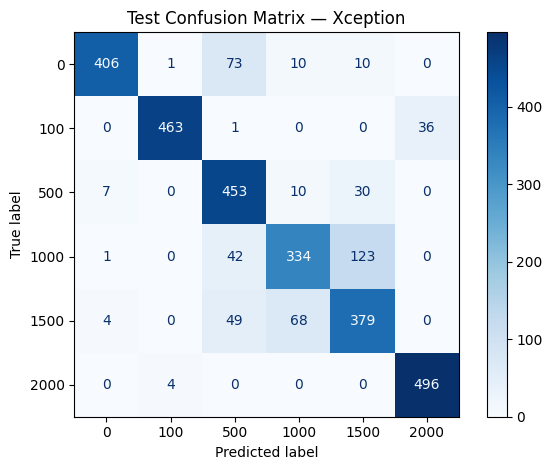


Classification Report — Xception:
              precision    recall  f1-score   support

           0     0.9713    0.8120    0.8845       500
         100     0.9893    0.9260    0.9566       500
         500     0.7330    0.9060    0.8104       500
        1000     0.7915    0.6680    0.7245       500
        1500     0.6993    0.7580    0.7274       500
        2000     0.9323    0.9920    0.9612       500

    accuracy                         0.8437      3000
   macro avg     0.8528    0.8437    0.8441      3000
weighted avg     0.8528    0.8437    0.8441      3000



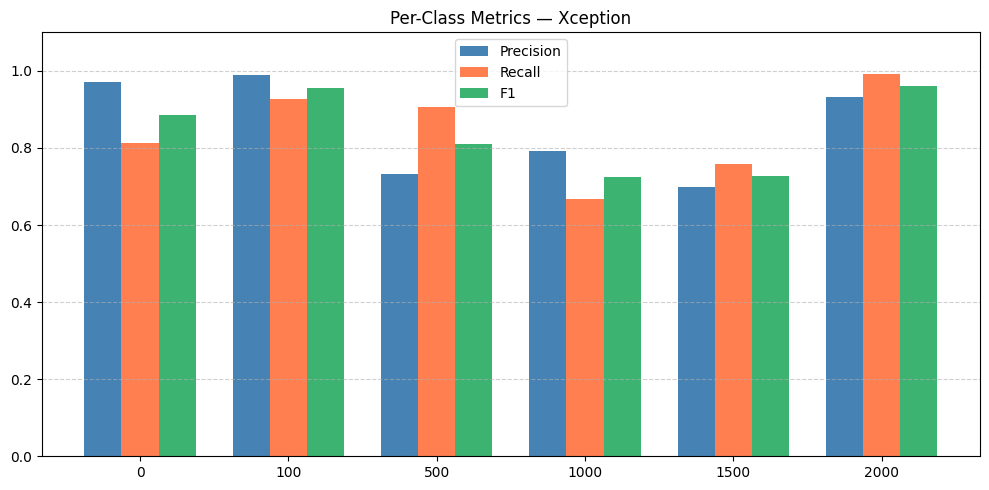

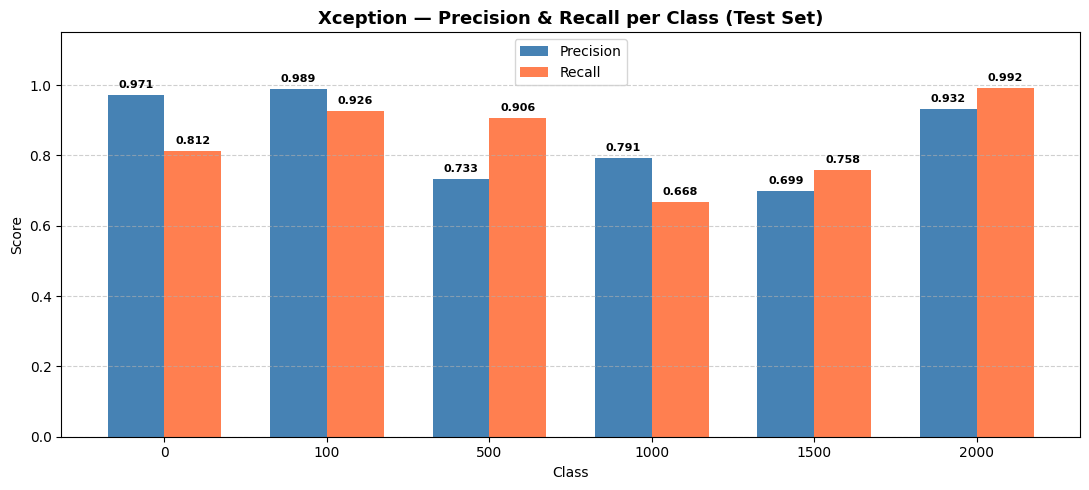

Precision & recall graph saved.


/tmp/ipykernel_18018/720686598.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_18018/720686598.py:137: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Xception — Inference Time per Image
  Images timed : 100
  Average      : 6.555 ms / image
  Std Dev      : 0.444 ms
  Min          : 5.716 ms
  Max          : 7.572 ms

FINAL SUMMARY
Accuracy           : 84.37%
Macro Precision    : 85.28%
Macro Recall       : 84.37%
Macro F1-score     : 84.41%
Parameters         : 21,069,998 total | 21,069,998 trainable
Model size         : 80.678 MB
Inference time     : 6.555 ms/image
Device             : cuda | NVIDIA GeForce RTX 3050 Ti Laptop GPU
Results saved in: /home/jenarththan/Desktop/FYP/May11/Notebooks/Xception_May11_Results


In [6]:
# ================================================
# Cell 6 — Test Evaluation + Reports + Graphs + Inference Time
# ================================================
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
sample_idx = 0

print("\n" + "="*65)
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)

# torch.no_grad() disables gradient tracking, saving memory
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference", leave=False):
        inputs = inputs.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        for i in range(len(preds)):
            true_name = CLASS_NAMES[labels[i]]
            pred_name = CLASS_NAMES[preds[i]]
            correct = "YES" if preds[i] == labels[i].item() else "NO "
            print(f"{sample_idx:>6}  {true_name:>12}  {pred_name:>12}  {correct:>8}")
            sample_idx += 1

print("="*65)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
test_acc = (all_preds == all_labels).mean()
print(f"\nTest Accuracy (Xception): {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")


# ── Confusion matrix ───────────────────────────────────────────
# Predicted vs true class counts for all 6 milling classes.
# ── Confusion Matrix ──
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title("Test Confusion Matrix — Xception")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_xception.png"), dpi=150)
plt.show()


# ── Full classification report ─────────────────────────────────
# Per-class precision, recall, F1-score and support.
# Saved as both .txt (human-readable) and .csv (for analysis).
# ── Classification Report ──
report_txt = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
print("\nClassification Report — Xception:")
print(report_txt)
with open(os.path.join(OUTPUT_DIR, "classification_report_xception.txt"), "w") as f:
    f.write(report_txt)
report_df = pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose()
report_df.to_csv(os.path.join(OUTPUT_DIR, "classification_report_xception.csv"))


# ── Per-class metric bar charts ────────────────────────────────
# Grouped bar charts show precision, recall and F1 for each class.
# ── Per-class metrics ──
precision = precision_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
recall = recall_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
f1 = f1_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, precision, w, label='Precision', color='steelblue')
plt.bar(x, recall, w, label='Recall', color='coral')
plt.bar(x + w, f1, w, label='F1', color='mediumseagreen')
plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.1)
plt.title("Per-Class Metrics — Xception")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_metrics_xception.png"), dpi=150)
plt.show()

w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, precision, w2, label='Precision', color='steelblue')
plt.bar(x + w2/2, recall, w2, label='Recall', color='coral')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, precision[i] + 0.02, f'{precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, recall[i] + 0.02, f'{recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.15)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Xception — Precision & Recall per Class (Test Set)", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_xception.png"), dpi=150)
plt.show()
print("Precision & recall graph saved.")


# ── Save raw predictions and class probabilities ───────────────
# Per-sample predictions with softmax probabilities for all 6 classes.
# ── Raw predictions CSV ──
pred_df = pd.DataFrame({
    "Sample": range(len(all_labels)),
    "True Label": [CLASS_NAMES[i] for i in all_labels],
    "Pred Label": [CLASS_NAMES[i] for i in all_preds],
    "Correct": (all_preds == all_labels).astype(int),
})
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    pred_df[f"Prob_{cls_name}"] = all_probs[:, cls_idx]
pred_df.to_csv(os.path.join(OUTPUT_DIR, "predictions_xception.csv"), index=False)

# ================================================
# Inference Time — 100 random test samples, per image
# ================================================
num_timing = min(100, len(test_ds))
_rng100 = np.random.RandomState(SEED)
_sample_idx = _rng100.choice(len(test_ds), num_timing, replace=False)
_timing_loader = DataLoader(Subset(test_ds, _sample_idx), batch_size=1,
                            shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)

# torch.no_grad() disables gradient tracking, saving memory
with torch.no_grad():
    _warm, _ = next(iter(_timing_loader))
    _warm = _warm.to(DEVICE)
    with torch.cuda.amp.autocast(enabled=use_amp):
        _ = model(_warm)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

inference_times_ms = []
model.eval()
# torch.no_grad() disables gradient tracking, saving memory
with torch.no_grad():
    for _inp, _ in _timing_loader:
        _inp = _inp.to(DEVICE)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        _t0 = time.perf_counter()
        with torch.cuda.amp.autocast(enabled=use_amp):
            _ = model(_inp)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        inference_times_ms.append((time.perf_counter() - _t0) * 1000)

avg_time_ms = float(np.mean(inference_times_ms))
std_time_ms = float(np.std(inference_times_ms))

print("\n" + "="*58)
print("Xception — Inference Time per Image")
print("="*58)
print(f"  Images timed : {num_timing}")
print(f"  Average      : {avg_time_ms:.3f} ms / image")
print(f"  Std Dev      : {std_time_ms:.3f} ms")
print(f"  Min          : {np.min(inference_times_ms):.3f} ms")
print(f"  Max          : {np.max(inference_times_ms):.3f} ms")
print("="*58)

pd.DataFrame({"sample": range(num_timing), "inference_time_ms": inference_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, "xception_inference_times.csv"), index=False)
pd.DataFrame({
    "Stage": ["Xception"],
    "Avg_ms_per_image": [round(avg_time_ms, 4)],
    "Std_ms": [round(std_time_ms, 4)],
    "Min_ms": [round(float(np.min(inference_times_ms)), 4)],
    "Max_ms": [round(float(np.max(inference_times_ms)), 4)],
}).to_csv(os.path.join(OUTPUT_DIR, "inference_time_summary.csv"), index=False)


# ── Aggregate metrics summary ──────────────────────────────────
# Macro and weighted averages exported with model and device info.
# ── Final metrics summary ──
macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_recall = recall_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_precision = precision_score(all_labels, all_preds, average='weighted')
weighted_recall = recall_score(all_labels, all_preds, average='weighted')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

metrics_summary = pd.DataFrame([{
    "accuracy": test_acc,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_precision": weighted_precision,
    "weighted_recall": weighted_recall,
    "weighted_f1": weighted_f1,
    "avg_inference_ms_per_image": avg_time_ms,
    "total_parameters": TOTAL_PARAMS,
    "trainable_parameters": TRAINABLE_PARAMS,
    "model_size_mb": MODEL_SIZE_MB,
    "device_used": str(DEVICE),
    "graphics_card": gpu_name,
}])
metrics_summary.to_csv(os.path.join(OUTPUT_DIR, "metrics_summary_xception.csv"), index=False)

print("\nFINAL SUMMARY")
print("=" * 70)
print(f"Accuracy           : {test_acc * 100:.2f}%")
print(f"Macro Precision    : {macro_precision * 100:.2f}%")
print(f"Macro Recall       : {macro_recall * 100:.2f}%")
print(f"Macro F1-score     : {macro_f1 * 100:.2f}%")
print(f"Parameters         : {TOTAL_PARAMS:,} total | {TRAINABLE_PARAMS:,} trainable")
print(f"Model size         : {MODEL_SIZE_MB:.3f} MB")
print(f"Inference time     : {avg_time_ms:.3f} ms/image")
print(f"Device             : {DEVICE} | {gpu_name}")
print("=" * 70)
print("Results saved in:", OUTPUT_DIR)


In [7]:
# ================================================
# Cell 7 — Feature Extraction  (save embeddings)
# ================================================
# ── Embedding extraction ───────────────────────────────────────
# Extracts 128-d embeddings using return_embedding=True.
# Saved as .npy files for PCA visualisation and SVM training.
def extract_embeddings(loader, model, split_name):
    model.eval()
    embs, ys = [], []
    # torch.no_grad() disables gradient tracking, saving memory
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Extracting [{split_name}]", leave=False):
            inputs = inputs.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                _, emb = model(inputs, return_embedding=True)
            embs.append(emb.cpu().float().numpy())
            ys.append(labels.numpy())
    return np.concatenate(embs, axis=0), np.concatenate(ys, axis=0)

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

train_embs, train_y = extract_embeddings(train_eval_loader, model, "train")
val_embs, val_y = extract_embeddings(val_loader, model, "val")
test_embs, test_y = extract_embeddings(test_loader, model, "test")

print(f"Embedding shapes -> train: {train_embs.shape}  val: {val_embs.shape}  test: {test_embs.shape}")

for name, arr in [
    ("train_embs", train_embs), ("val_embs", val_embs), ("test_embs", test_embs),
    ("train_y", train_y), ("val_y", val_y), ("test_y", test_y),
]:
    np.save(os.path.join(OUTPUT_DIR, f"{name}.npy"), arr)
    print(f"  Saved {name}.npy  shape={arr.shape}")

print("\nAll embeddings saved.")


Extracting [train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_18018/406030973.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Extracting [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Extracting [test]:   0%|          | 0/94 [00:00<?, ?it/s]

Embedding shapes -> train: (10500, 128)  val: (1500, 128)  test: (3000, 128)
  Saved train_embs.npy  shape=(10500, 128)
  Saved val_embs.npy  shape=(1500, 128)
  Saved test_embs.npy  shape=(3000, 128)
  Saved train_y.npy  shape=(10500,)
  Saved val_y.npy  shape=(1500,)
  Saved test_y.npy  shape=(3000,)

All embeddings saved.


In [8]:
# ================================================
# Cell 8 — Saved Artifact Listing
# ================================================
# List all files saved to OUTPUT_DIR with their sizes for verification
print("\n" + "="*60)
print("Xception saved artifacts")
print("="*60)
for item in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, item)
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024 ** 2)
        print(f"{item:45} {size_mb:10.3f} MB")
    else:
        print(item)
print("="*60)



Xception saved artifacts
best_xception_model.pth                           80.678 MB
classification_report_xception.csv                 0.001 MB
classification_report_xception.txt                 0.001 MB
confusion_matrix_xception.png                      0.050 MB
inference_time_summary.csv                         0.000 MB
metrics_summary_xception.csv                       0.000 MB
model_device_size_summary.csv                      0.000 MB
per_class_metrics_xception.png                     0.029 MB
precision_recall_xception.png                      0.052 MB
predictions_xception.csv                           0.190 MB
test_embs.npy                                      1.465 MB
test_y.npy                                         0.023 MB
train_embs.npy                                     5.127 MB
train_y.npy                                        0.080 MB
training_curves.png                                0.070 MB
training_history.csv                               0.002 MB
val_embs.npy  

Embeddings : (3000, 128)
True labels: (3000,)
Classes    : ['0', '100', '500', '1000', '1500', '2000']
PCA output : /home/jenarththan/Desktop/FYP/May11/Notebooks/Xception_May11_Results/PCA_Analysis

Explained variance: PC1=0.482  PC2=0.252  Total=0.734


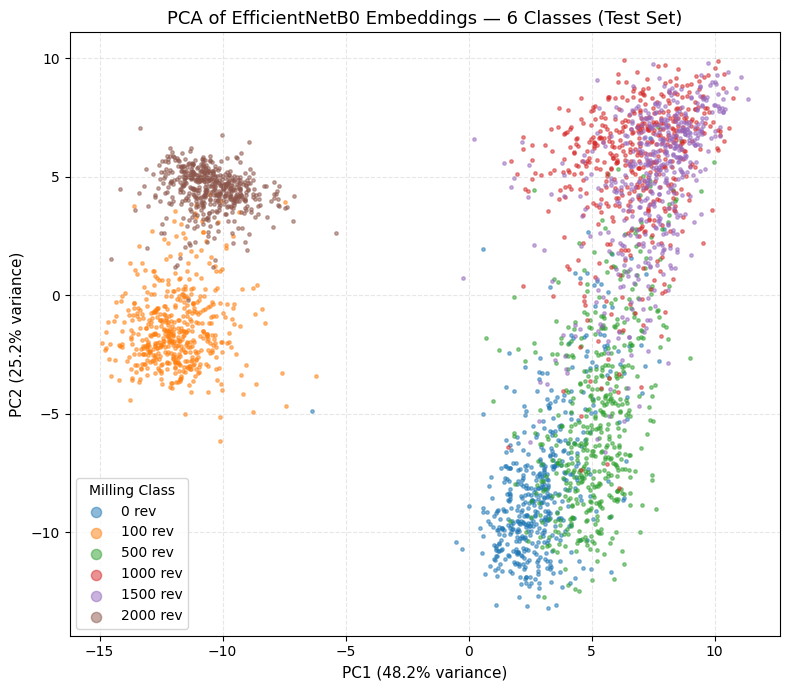

Saved: pca_embeddings.png


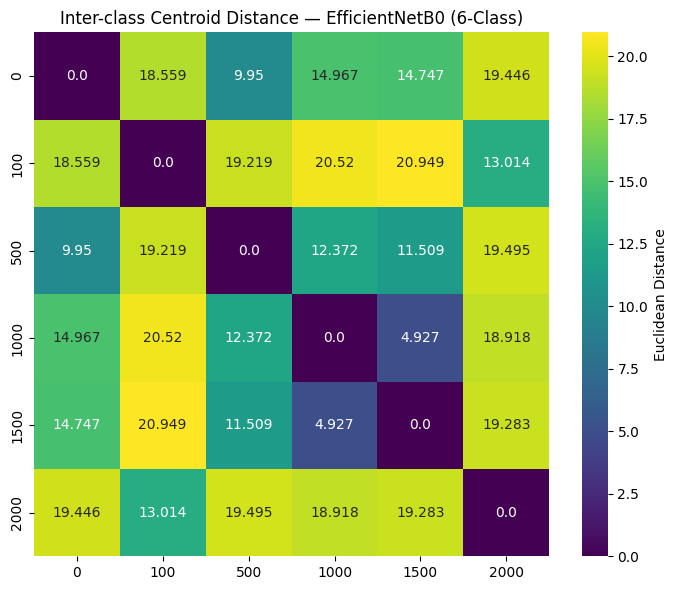

Saved: distance_heatmap.png


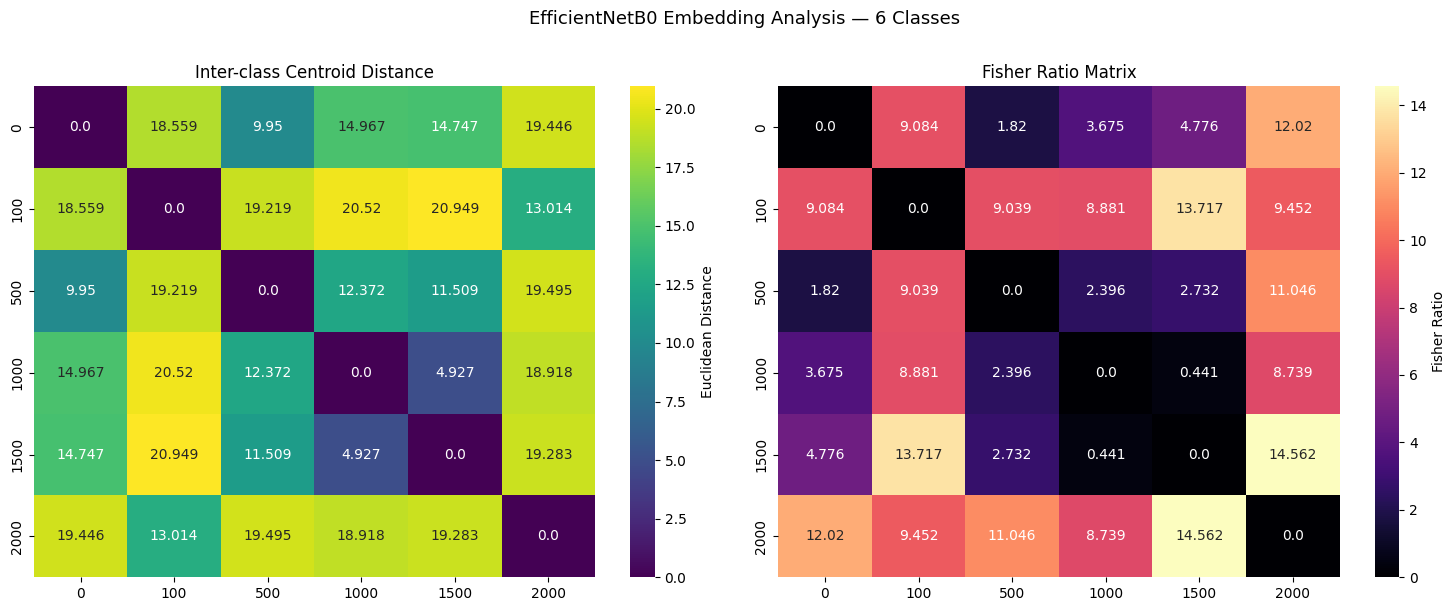

Saved: distance_fisher_side_by_side.png


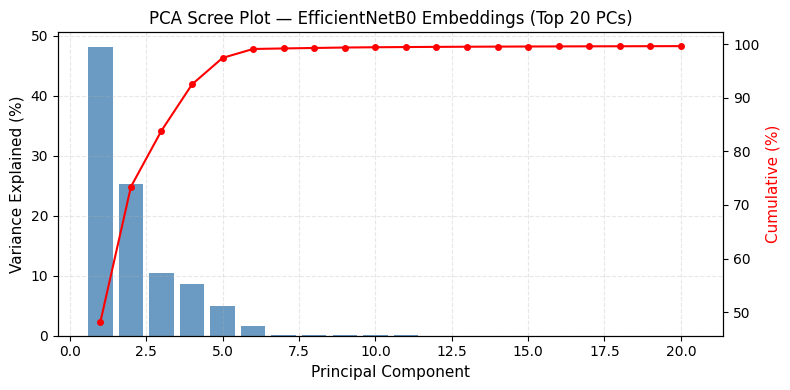

Saved: pca_scree_plot.png

All PCA results saved to: /home/jenarththan/Desktop/FYP/May11/Notebooks/Xception_May11_Results/PCA_Analysis
PC1+PC2 explains : 73.4%
PCs for 95% var  : 5


In [9]:
# ================================================
# Cell 9 — PCA Analysis of Embeddings
# ================================================
# ── Additional libraries for PCA analysis ──────────────────────
# seaborn : heatmap for distance and Fisher matrices
# scipy   : pairwise Euclidean distances between class centroids
# sklearn.decomposition.PCA : dimensionality reduction for 2D plot
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from glob import glob

PCA_DIR = os.path.join(OUTPUT_DIR, "PCA_Analysis")
os.makedirs(PCA_DIR, exist_ok=True)


# ── Load precomputed embeddings ────────────────────────────────
# Decoupled from training — can re-run PCA independently.
# Load embeddings saved by Cell 7
test_embs = np.load(os.path.join(OUTPUT_DIR, "test_embs.npy"))
y_true    = np.load(os.path.join(OUTPUT_DIR, "test_y.npy"))

# Find predictions CSV saved by Cell 6
pred_csvs = glob(os.path.join(OUTPUT_DIR, "predictions_*.csv"))
assert pred_csvs, f"No predictions CSV found in {OUTPUT_DIR}. Run Cell 6 first."
pred_df   = pd.read_csv(pred_csvs[0])
label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
y_pred = np.array([label_to_idx[str(l)] for l in pred_df["Pred Label"].values])

COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'][:NUM_CLASSES]

print(f"Embeddings : {test_embs.shape}")
print(f"True labels: {y_true.shape}")
print(f"Classes    : {CLASS_NAMES}")
print(f"PCA output : {PCA_DIR}")


# ── PCA 2-D projection ─────────────────────────────────────────
# Projects 128-d embeddings onto 2 principal components.
# Well-separated clusters indicate discriminative learned features.
# ── PCA 2D scatter ──────────────────────────────
pca = PCA(n_components=2, random_state=42)
Z   = pca.fit_transform(test_embs)
var = pca.explained_variance_ratio_
print(f"\nExplained variance: PC1={var[0]:.3f}  PC2={var[1]:.3f}  Total={var.sum():.3f}")

fig, ax = plt.subplots(figsize=(8, 7))
for i, name in enumerate(CLASS_NAMES):
    idx = (y_true == i)
    ax.scatter(Z[idx, 0], Z[idx, 1], s=6, alpha=0.5, label=f'{name} rev', color=COLORS[i])
ax.set_title(f'PCA of EfficientNetB0 Embeddings — {NUM_CLASSES} Classes (Test Set)', fontsize=13)
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)', fontsize=11)
ax.legend(markerscale=3, fontsize=10, title='Milling Class')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_embeddings.png"), dpi=300)
plt.show()
print("Saved: pca_embeddings.png")


# ── Inter-class centroid distance matrix ───────────────────────
# Euclidean distance between class mean embeddings in 128-d space.
# Large inter / small intra distances indicate good class separation.
# ── Centroid distances ──────────────────────────
centroids, intra_spread = [], []
for i in range(NUM_CLASSES):
    Xc = test_embs[y_true == i]
    mu = Xc.mean(axis=0)
    centroids.append(mu)
    intra_spread.append(np.mean(np.linalg.norm(Xc - mu, axis=1)))
centroids    = np.vstack(centroids)
intra_spread = np.array(intra_spread)

inter   = cdist(centroids, centroids, metric='euclidean')
dist_df = pd.DataFrame(inter, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=ax,
            cbar_kws={'label': 'Euclidean Distance'})
ax.set_title(f'Inter-class Centroid Distance — EfficientNetB0 ({NUM_CLASSES}-Class)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_heatmap.png"), dpi=300)
plt.show()
print("Saved: distance_heatmap.png")


# ── Fisher Discriminant Ratio ──────────────────────────────────
# Fisher = (inter-class distance)^2 / (sum of intra-class variances)
# High ratio = classes well-separated relative to internal scatter.
# ── Fisher ratio ────────────────────────────────
intra_var = intra_spread ** 2
F = np.zeros((NUM_CLASSES, NUM_CLASSES))
for a in range(NUM_CLASSES):
    for b in range(NUM_CLASSES):
        if a != b:
            F[a, b] = (inter[a, b] ** 2) / (intra_var[a] + intra_var[b] + 1e-8)
fish_df = pd.DataFrame(F, index=CLASS_NAMES, columns=CLASS_NAMES)


# Combined distance + Fisher heatmaps side by side for the paper figure
# ── Side-by-side ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=axes[0],
            cbar_kws={'label': 'Euclidean Distance'})
axes[0].set_title('Inter-class Centroid Distance', fontsize=12)
sns.heatmap(fish_df.round(3), annot=True, fmt='', cmap='magma', ax=axes[1],
            cbar_kws={'label': 'Fisher Ratio'})
axes[1].set_title('Fisher Ratio Matrix', fontsize=12)
fig.suptitle(f'EfficientNetB0 Embedding Analysis — {NUM_CLASSES} Classes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_fisher_side_by_side.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: distance_fisher_side_by_side.png")


# ── PCA scree plot ─────────────────────────────────────────────
# Variance explained per PC (bar) and cumulative (red line).
# Determines how many PCs capture 95% of embedding variance.
# ── Scree plot ──────────────────────────────────
pca_full = PCA(random_state=42).fit(test_embs)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax  = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 21), pca_full.explained_variance_ratio_[:20]*100, color='steelblue', alpha=0.8, label='Individual')
ax2 = ax.twinx()
ax2.plot(range(1, 21), cum_var[:20]*100, color='red', marker='o', ms=4, label='Cumulative')
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Variance Explained (%)', fontsize=11)
ax2.set_ylabel('Cumulative (%)', fontsize=11, color='red')
ax.set_title('PCA Scree Plot — EfficientNetB0 Embeddings (Top 20 PCs)', fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_scree_plot.png"), dpi=150)
plt.show()
print("Saved: pca_scree_plot.png")


# Export all PCA results to CSV for reproducibility and further analysis
# ── Save CSVs ───────────────────────────────────
dist_df.to_csv(os.path.join(PCA_DIR, "pairwise_centroid_distance.csv"))
fish_df.to_csv(os.path.join(PCA_DIR, "pairwise_fisher_ratio.csv"))
pd.DataFrame({'Class': CLASS_NAMES, 'Intra_spread': intra_spread.round(4),
              'N_samples': [int(np.sum(y_true == i)) for i in range(NUM_CLASSES)]
}).to_csv(os.path.join(PCA_DIR, "class_spread_summary.csv"), index=False)
pd.DataFrame({'PC1': Z[:,0], 'PC2': Z[:,1],
              'True_Label': [CLASS_NAMES[i] for i in y_true]
}).to_csv(os.path.join(PCA_DIR, "pca_coordinates.csv"), index=False)

print(f"\nAll PCA results saved to: {PCA_DIR}")
n_95 = int(np.searchsorted(cum_var, 0.95)) + 1
print(f"PC1+PC2 explains : {cum_var[1]*100:.1f}%")
print(f"PCs for 95% var  : {n_95}")